<a href="https://colab.research.google.com/github/miso-20/ESSA/blob/main/ESAA_YB_3%EC%A1%B0_summer_project_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. 데이터 개요



### (1) 데이터 출처
- 제공 기관: GES DISC (Goddard Earth Sciences Data and Information Services Center)

- 데이터셋 명: MERRA-2 tavgM_2d_ocn_Nx (단축명: M2TMNXOCN)

- 버전: Version 5.12.4

- 고유 식별자 (DOI): 10.5067/4IASLIDL8EEC

### (2) 분석 기간 및 범위
- 분석 기간: 2000년 ~ 2026년

- 분석 범위: 북극(위도 60°N~90°N)


### (3) 데이터 전처리 (1차)
- NetCDF(.nc4) 형식의 원본 데이터를 Python(xarray)을 이용하여 불러왔다.

- 북극 지역(위도 60°N~90°N)만 추출하여 분석 범위를 설정하였다.

- 각 월별 자료에 대해 공간평균(Spatial Mean)을 계산하여 북극 전체를 대표하는 시계열 데이터로 변환하였다.

- 여러 개의 월별 데이터를 하나의 CSV 파일로 통합하여 분석용 데이터셋을 구축하였다.

- 분석에 필요한 변수만 선별하고 날짜(time)를 datetime 형식으로 변환한 후 오름차순으로 정렬하여 최종 분석 데이터를 생성하였다.











### (4) 변수
- time : 관측 시간 (년-월)

- FRSEAICE : 북극 해빙 면적 비율 (해당 해역에 바다 얼음이 덮여있는 비율)

- TSKINWTR : 해수면 온도 (얼음이 없는 순수한 바닷물의 온도)

- T10M : 10m 상공의 기온 (바다 위 대기 온도)

- HFLUXWTR : 해수면의 현열 플럭스 (대기와 바닷물의 온도 차이로 주고받는 열에너지)

- EFLUXWTR : 해수면의 잠열 플럭스 (바닷물이 증발할 때 발생하는 열에너지)

- U10M : 10m 상공의 동서 방향 바람 속도

- V10M : 10m 상공의 남북 방향 바람 속도

※ 현열 플럭스는 바다와 대기의 온도 차이에 의해 전달되는 열에너지이며, 잠열 플럭스는 해수의 증발 과정에서 전달되는 열에너지를 의미한다.


# 2. EDA

데이터 가공을 통해 생성한 북극 해수면 온도 데이터(Arctic_SST_Analysis_Data.csv)를 이용하여 EDA를 수행하였다. 장기 추세와 계절성을 분석하기 위해 연도(Year)와 월(Month) 변수를 생성하여 데이터를 분석 가능한 형태로 구성하였다.


In [ ]:
!pip install koreanize-matplotlib -q

import warnings
warnings.filterwarnings(action='ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 설정
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

import koreanize_matplotlib # 한글 폰트 적용


file_path = '/content/drive/MyDrive/YB_data/Summer_Project/Arctic_SST_Analysis_Data.csv'
df = pd.read_csv(file_path)
df['time'] = pd.to_datetime(df['time'])
df['Year'] = df['time'].dt.year
df['Month'] = df['time'].dt.month
df.set_index('time', inplace=True)

**시간에 따른 해수면 온도 변화**

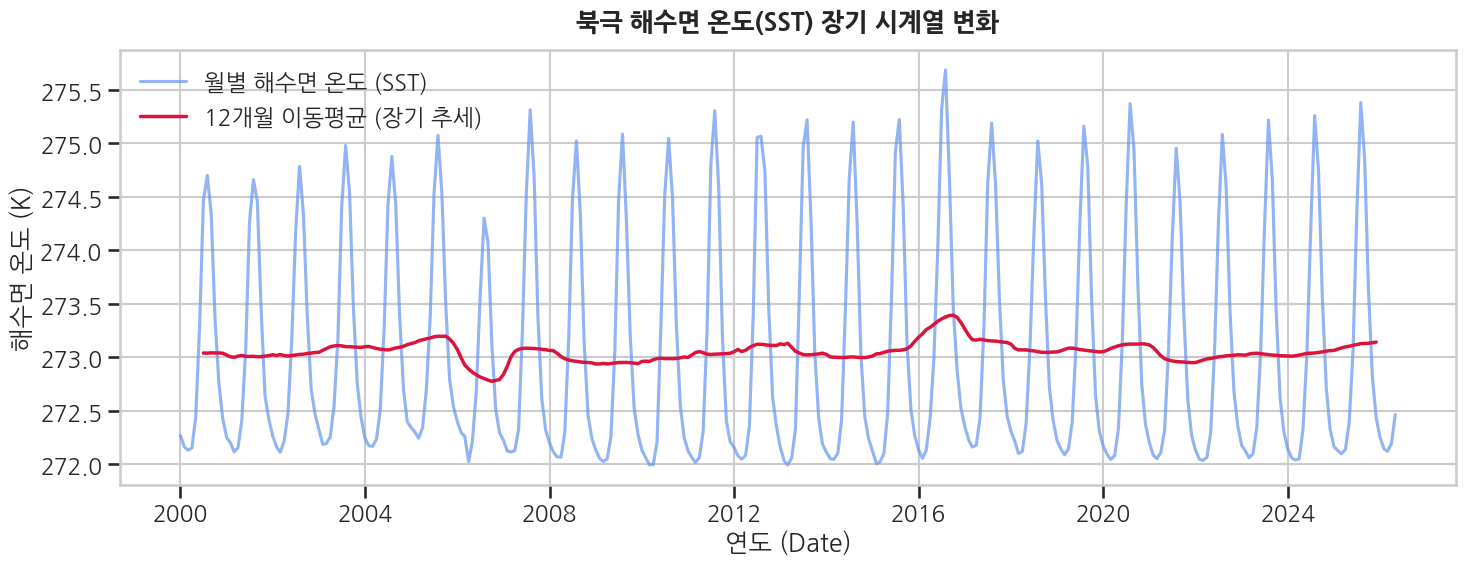

In [ ]:
# 1. 전체 시계열 그래프 (장기 추세, 계절성, 이상치 확인)
plt.figure(figsize=(15, 6))

# 원본 데이터 라인 그래프
plt.plot(df.index, df['TSKINWTR'], color='cornflowerblue', alpha=0.7, label='월별 해수면 온도 (SST)')

# 12개월 이동평균선 (장기 추세를 더 선명하게 보기 위해 추가)
df['TSKINWTR_roll12'] = df['TSKINWTR'].rolling(window=12, center=True).mean()
plt.plot(df.index, df['TSKINWTR_roll12'], color='crimson', linewidth=2.5, label='12개월 이동평균 (장기 추세)')

plt.title('북극 해수면 온도(SST) 장기 시계열 변화', fontweight='bold', pad=15)
plt.xlabel('연도 (Date)')
plt.ylabel('해수면 온도 (K)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

전체 관측 기간(2000~2026년, 단 2026년은 일부 월만 포함)을 대상으로 한 월별 해수면 온도 시계열 그래프를 확인한 결과, 1년을 주기로 하는 뚜렷하고 규칙적인 계절 진폭이 관찰된다. 계절적 변동성을 제거하고 기저에 깔린 장기 추세를 파악하기 위해 적용한 12개월 이동평균선을 살펴보면 전체적으로 273K 부근에서 변동하지만, 장기적으로는 완만한 상승 추세를 나타낸다. 특히 2007년경 일시적인 하락 이후 점진적으로 상승하여 2016년경 가장 높은 수준에 도달하였다.



**월별 해수면 온도 분포 (계절성 및 이상치 확인)**

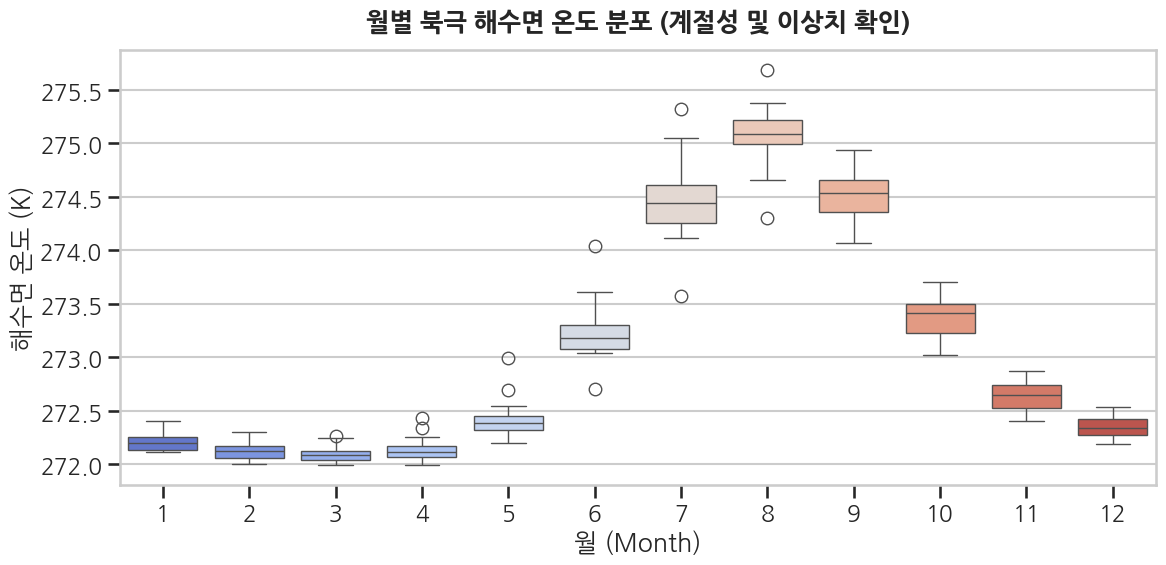

In [ ]:
# 2. 월별 Boxplot (월별 온도 분포 및 계절성 확인)
plt.figure(figsize=(12, 6))

# Boxplot 생성 (coolwarm 팔레트로 온도 느낌 강조)
sns.boxplot(x='Month', y='TSKINWTR', data=df, palette='coolwarm')

plt.title('월별 북극 해수면 온도 분포 (계절성 및 이상치 확인)', fontweight='bold', pad=15)
plt.xlabel('월 (Month)')
plt.ylabel('해수면 온도 (K)')

plt.tight_layout()
plt.show()

월별 온도의 분포를 박스플롯으로 시각화한 결과, 북극 해수면 온도의 계절적 특성이 명확하게 드러난다. 1월부터 5월까지는 272K 부근에서 온도가 낮고 변동폭이 좁게 유지되나 6월부터 급격히 상승하여 8월에 연중 최고점(중앙값 기준 약 275.1K)에 도달한다. 주목할 점은 5월~8월 및 10월의 박스플롯 상단에서 다수의 극단 이상치가 관측된다는 점이다. 일부 연도에서 상대적으로 높은 온도값이 관측되었음을 의미한다.


**연도별 평균 해수면 온도 변화 (온난화 추세)**

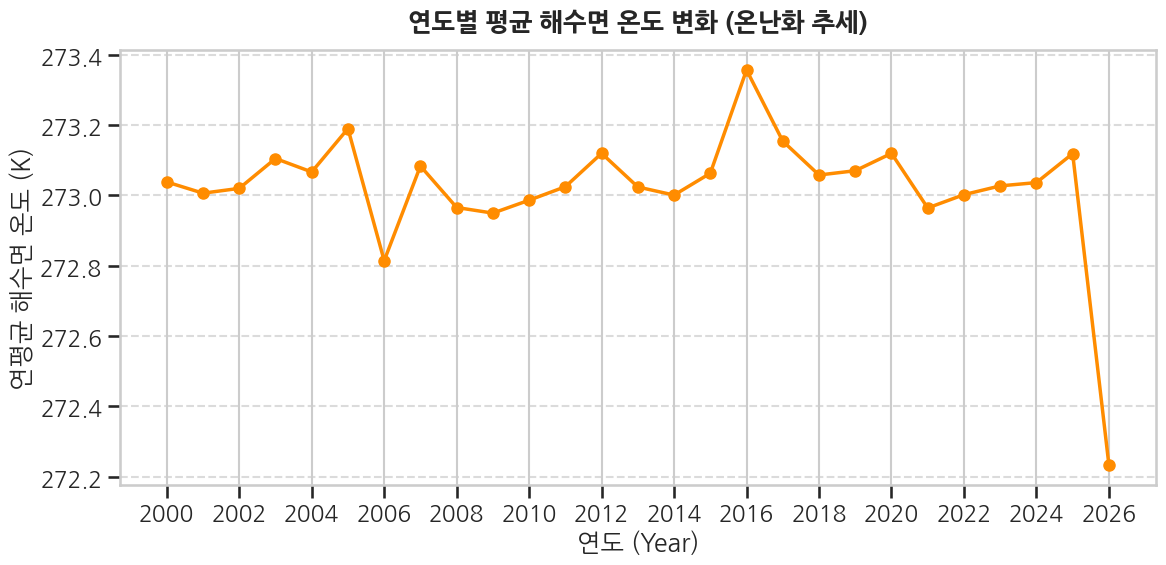

In [ ]:
# 3. 연도별 평균 SST (장기적인 온난화 추세 확인)
plt.figure(figsize=(12, 6))

# 연도별 평균 계산
yearly_mean = df.groupby('Year')['TSKINWTR'].mean()

# 추세 그래프 (마커 추가)
plt.plot(yearly_mean.index, yearly_mean.values, marker='o', markersize=8,
         color='darkorange', linestyle='-', linewidth=2.5)

plt.title('연도별 평균 해수면 온도 변화 (온난화 추세)', fontweight='bold', pad=15)
plt.xlabel('연도 (Year)')
plt.ylabel('연평균 해수면 온도 (K)')

# x축 연도 눈금 깔끔하게 설정
plt.xticks(np.arange(yearly_mean.index.min(), yearly_mean.index.max()+1, 2))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

연도별 평균 온도를 산출하여 장기적인 변화를 분석한 결과, 전반적인 변동성 속에서도 2005년과 2016년에 두드러진 고온 현상이 나타났다. 특히 2016년은 전체 관측 기간 중 가장 높은 연평균 해수면 온도를 기록하여 가장 높은 연평균 해수면 온도를 기록하였다. 그래프 우측 끝인 2026년의 경우 연평균 온도가 272.2K 수준으로 급격히 하락한 것처럼 보이나 이는 기후적인 급랭 현상이 아닌 데이터 수집 기간의 한계로 인한 통계적 착시로 판단된다.



**연도 및 월별 해수면 온도 변화 히트맵 분석**

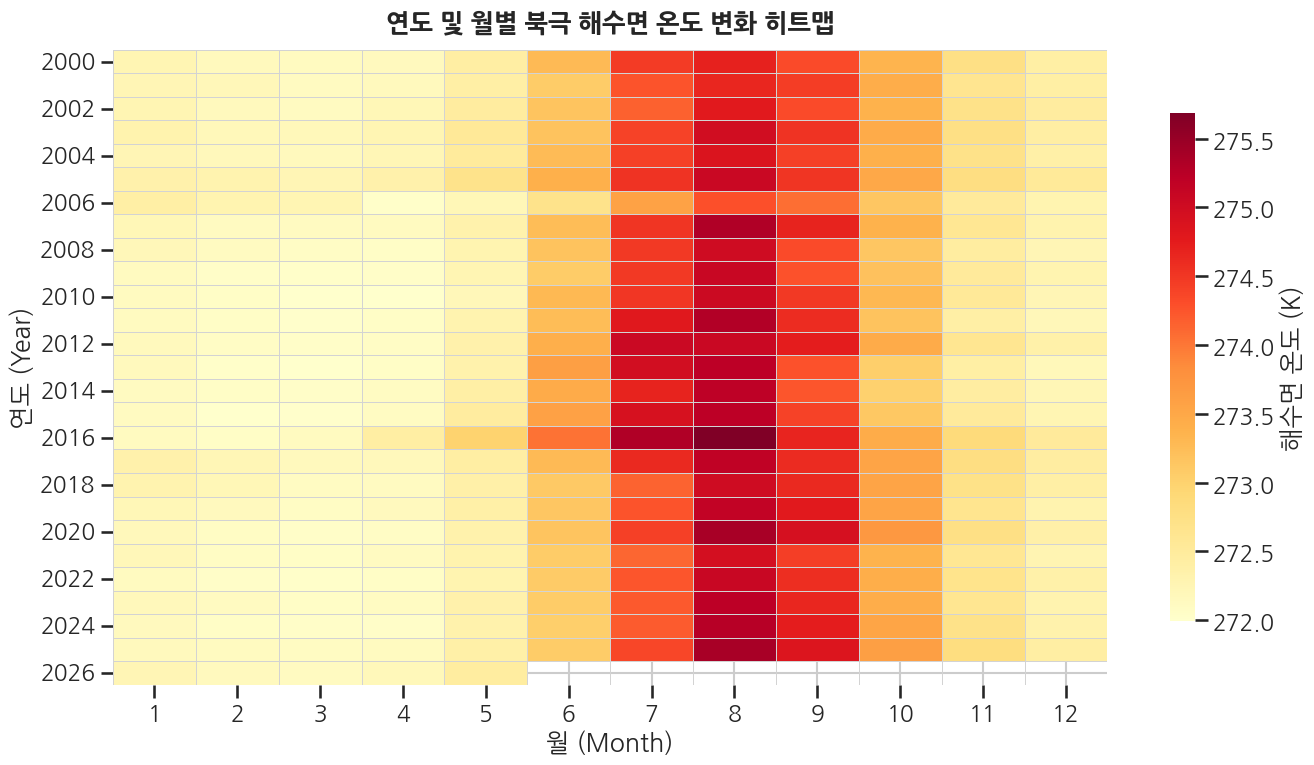

In [ ]:
# 4. 히트맵 (Year × Month)
plt.figure(figsize=(14, 8))

# 데이터 피벗 (행: 연도, 열: 월)
sst_pivot = df.pivot_table(values='TSKINWTR', index='Year', columns='Month')

# 히트맵 생성 (YlOrRd: 노란색에서 붉은색으로 갈수록 뜨거움을 표현)
sns.heatmap(sst_pivot, cmap='YlOrRd', linewidths=0.5, linecolor='lightgray',
            cbar_kws={'label': '해수면 온도 (K)', 'shrink': 0.8})

plt.title('연도 및 월별 북극 해수면 온도 변화 히트맵', fontweight='bold', pad=15)
plt.xlabel('월 (Month)')
plt.ylabel('연도 (Year)')

plt.tight_layout()
plt.show()

히트맵에서는 매년 7~9월에 붉은색의 고온 영역이 반복적으로 나타나며 북극 해수면 온도의 뚜렷한 계절성을 확인할 수 있다.
앞서 발견된 2026년 연평균 온도 급락의 원인이 명확히 규명된다.
최하단 2026년 행을 보면 6월 이후의 데이터가 존재하지 않아 빈칸으로 처리되어 있다.

즉, 연중 온도가 가장 높게 치솟는 7-9월 여름철 데이터가 평균 계산에서 누락되면서 1-5월의 저온 데이터만 반영되어 2026년 연평균이 비정상적으로 낮게 도출된 것이다. 따라서 장기 추세를 비교하거나 모델을 학습할 때는 2026년 자료의 불완전성을 고려하여 해석할 필요가 있다.

### 해수면 온도 EDA 결과 요약
탐색적 데이터 분석 결과 북극 해수면 온도는 뚜렷한 계절성을 가지며 여름철(7~9월)에 가장 높은 값을 나타냈다. 또한 장기적으로는 완만한 상승 경향이 확인되어 북극 해수면 온난화의 가능성을 시사하였다. 다만 2026년 자료는 일부 월만 포함되어 있어 연도별 평균 비교 시 해석에 주의가 필요하며 이후 모델링 과정에서도 이러한 데이터 특성을 고려하였다.
